In [2]:
from torch import nn
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn,optim
from torch.utils.data import Dataset, DataLoader

In [3]:
class Data(Dataset):
    def __init__(self, train=True):
        self.x = torch.arange(-3, 3, 0.1).view(-1, 1)
        self.f = -3 * self.x + 1
        self.y = self.x + 0.1 * torch.randn(self.x.size())
        self.len = self.x.shape[0]

        if train == True:
            self.y[0] = 0
            self.y[50:55] = 20
        else:
            pass

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return self.len

In [4]:
train_data = Data()
val_data = Data(train=False)

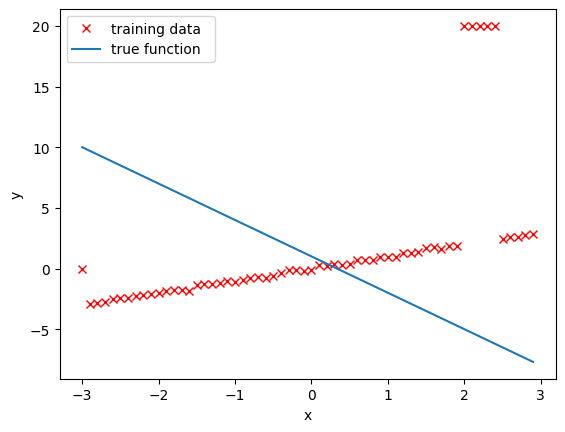

In [5]:
plt.plot(train_data.x.numpy(), train_data.y.numpy(), 'xr',label="training data ")
plt.plot(train_data.x.numpy(), train_data.f.numpy(),label="true function  ")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [6]:
from torch import nn

class linear_regression(nn.Module):
    def __init__(self, input_size, output_size):
        super(linear_regression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        yhat = self.linear(x)
        return yhat

In [7]:
criterion = nn.MSELoss()
trainloader = DataLoader(dataset=train_data, batch_size=1)
learning_rates = [0.0001, 0.001, 0.01, 0.1]
train_error=torch.zeros(len(learning_rates))
validation_error=torch.zeros(len(learning_rates))
MODELS=[]

In [9]:
def train_model_with_lr(iter, lr_list):
    for i , lr in enumerate(lr_list):
        model = linear_regression(1, 1)
        optimizer = optim.SGD(model.parameters(), lr=lr)
        for epoch in range(iter):
            for x, y in trainloader:
                yhat = model(x)
                loss = criterion(yhat, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            yhat = model(train_data.x)
            train_loss = criterion(yhat, train_data.y)
            train_error[i] = train_loss.item()

            yhat = model(val_data.x)
            val_loss = criterion(yhat, val_data.y)
            validation_error[i] = val_loss.item()
            MODELS.append(model)
train_model_with_lr(10, learning_rates)

<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Murti\AppData\Local\Temp\ipykernel_6464\529485961.py:3: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('Cost\ Total Loss')


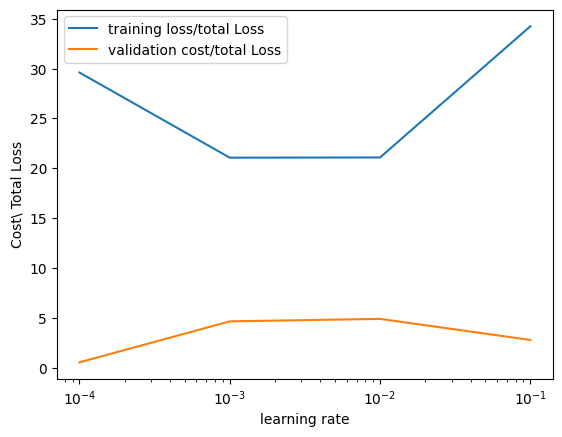

In [10]:
plt.semilogx(np.array(learning_rates), train_error.numpy(), label = 'training loss/total Loss')
plt.semilogx(np.array(learning_rates), validation_error.numpy(), label = 'validation cost/total Loss')
plt.ylabel('Cost\ Total Loss')
plt.xlabel('learning rate')
plt.legend()
plt.show()

0 [[-1.7202376]
 [-1.6620245]
 [-1.6038113]]
1 [[-1.7202376]
 [-1.6620245]
 [-1.6038113]]
2 [[-1.7202376]
 [-1.6620245]
 [-1.6038113]]
3 [[-1.7202376]
 [-1.6620245]
 [-1.6038113]]


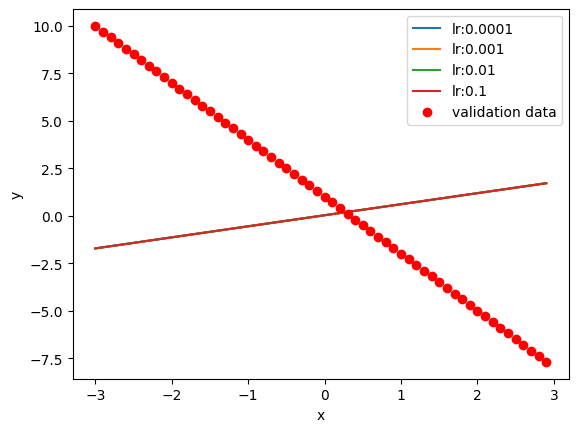

In [13]:
i = 0
for model, learning_rate in zip(MODELS, learning_rates):
    yhat = model(val_data.x)
    plt.plot(val_data.x.numpy(), yhat.detach().numpy(), label = 'lr:' + str(learning_rate))
    print(i, yhat.detach().numpy()[0:3])
    i+=1
plt.plot(val_data.x.numpy(), val_data.f.numpy(), 'or', label = 'validation data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [17]:
good_model = MODELS[np.argmin(validation_error)]
for x, y in trainloader:
    print("yhat= ", good_model(x),"y", y)

yhat=  tensor([[-1.7202]], grad_fn=<AddmmBackward0>) y tensor([[0.]])
yhat=  tensor([[-1.6620]], grad_fn=<AddmmBackward0>) y tensor([[-2.8923]])
yhat=  tensor([[-1.6038]], grad_fn=<AddmmBackward0>) y tensor([[-2.8290]])
yhat=  tensor([[-1.5456]], grad_fn=<AddmmBackward0>) y tensor([[-2.7323]])
yhat=  tensor([[-1.4874]], grad_fn=<AddmmBackward0>) y tensor([[-2.5193]])
yhat=  tensor([[-1.4292]], grad_fn=<AddmmBackward0>) y tensor([[-2.4060]])
yhat=  tensor([[-1.3710]], grad_fn=<AddmmBackward0>) y tensor([[-2.4557]])
yhat=  tensor([[-1.3127]], grad_fn=<AddmmBackward0>) y tensor([[-2.2888]])
yhat=  tensor([[-1.2545]], grad_fn=<AddmmBackward0>) y tensor([[-2.2188]])
yhat=  tensor([[-1.1963]], grad_fn=<AddmmBackward0>) y tensor([[-2.0624]])
yhat=  tensor([[-1.1381]], grad_fn=<AddmmBackward0>) y tensor([[-1.9939]])
yhat=  tensor([[-1.0799]], grad_fn=<AddmmBackward0>) y tensor([[-1.8481]])
yhat=  tensor([[-1.0217]], grad_fn=<AddmmBackward0>) y tensor([[-1.7472]])
yhat=  tensor([[-0.9635]], gra

In [16]:
np.argmin(validation_error)

tensor(0)